In [3]:
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder

In [18]:
titanic = sns.load_dataset("titanic")

features = ["pclass","sex","embarked","fare","age"] #only use this feature
target = ["survived"]

# handling missing data
imp_mediun = SimpleImputer(strategy="median")
titanic[['age']] = imp_mediun.fit_transform(titanic[['age']])

imp_frequent = SimpleImputer(strategy="most_frequent")
titanic[['embarked']] = imp_frequent.fit_transform(titanic[['embarked']])

# label encoding
le = LabelEncoder()
titanic['sex'] = le.fit_transform(titanic['sex'])
titanic['embarked'] = le.fit_transform(titanic['embarked'])

X = titanic[features]
y = titanic['survived']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [19]:
# decision tree

model = DecisionTreeClassifier()

model.fit(X_train, y_train)

y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)

print("Training Accuracy : ",accuracy_score(y_train, y_pred_train) * 100 ,"%")
print("Testing Accuracy : ",accuracy_score(y_test, y_pred_test) * 100 ,"%")

Training Accuracy :  97.91332263242376 %
Testing Accuracy :  76.49253731343283 %


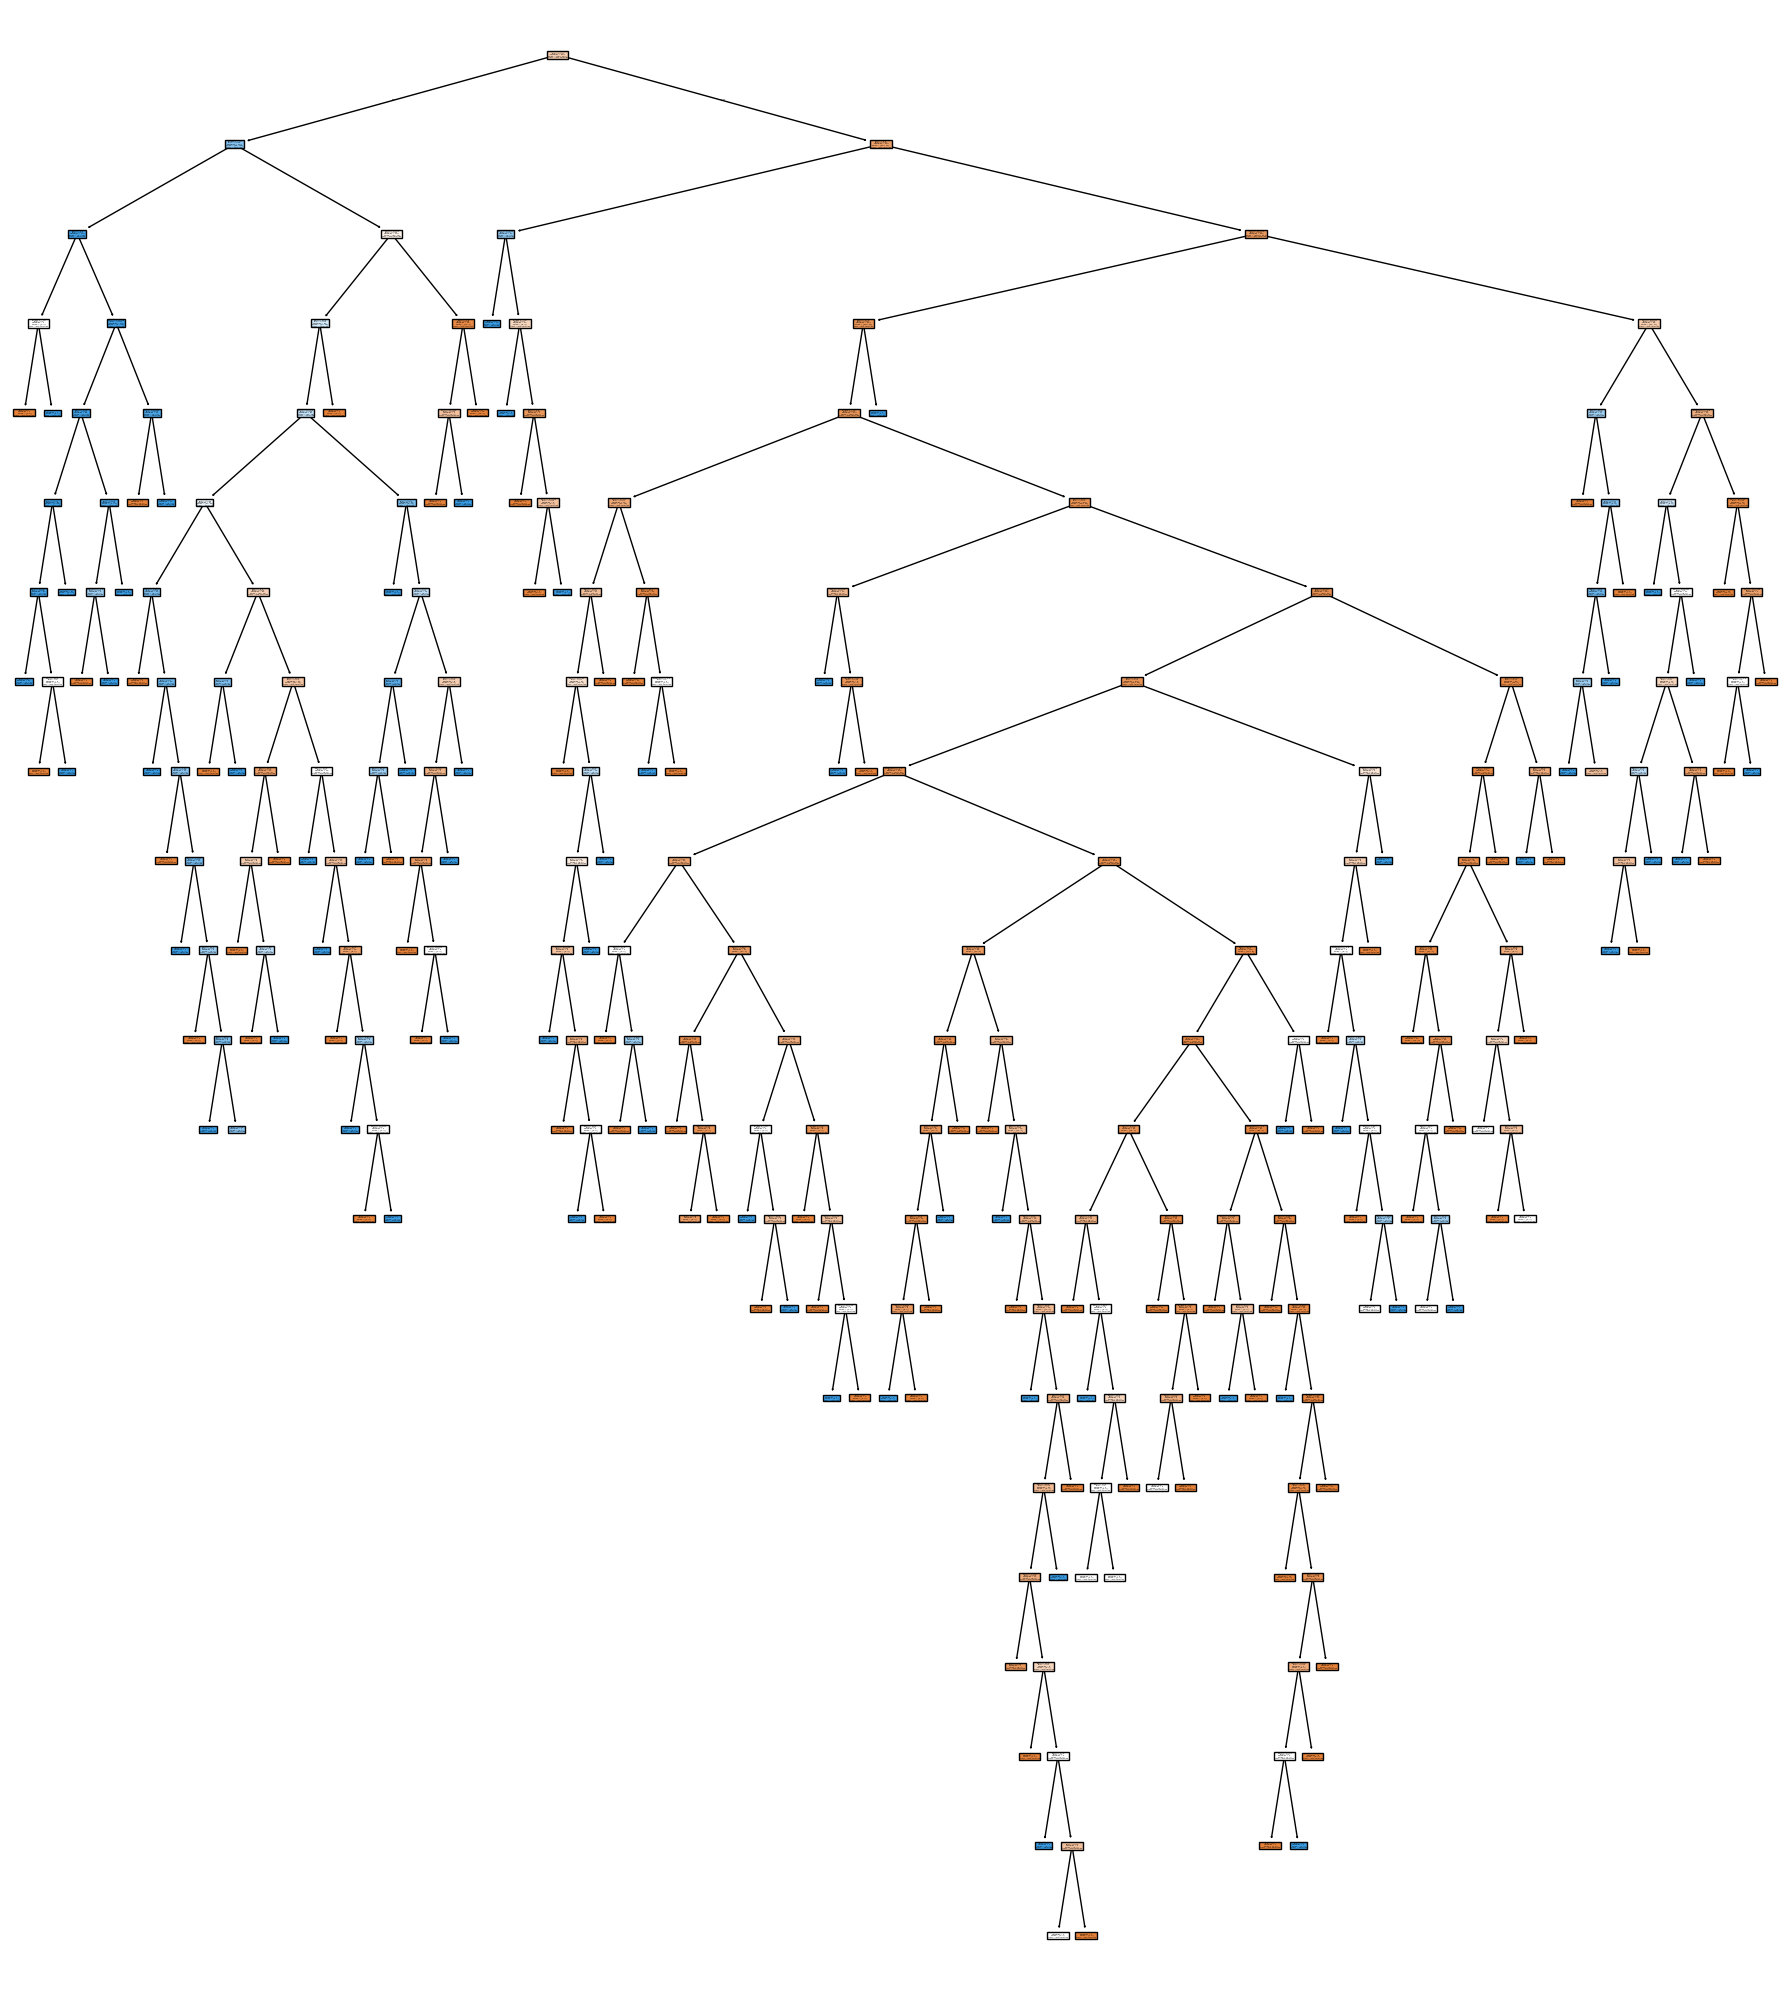

In [20]:
from sklearn.tree import plot_tree

plt.figure(figsize = (18,20))
plot_tree(
    model,
    feature_names = X.columns,
    class_names = ["Not Survived","Survived"],
    filled = True
)

plt.tight_layout()

In [21]:
# Random forest classifier
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=201, oob_score=True, bootstrap=True, random_state=42)

rf.fit(X_train, y_train)

RandomForestClassifier(n_estimators=201, oob_score=True, random_state=42)

In [25]:
y_pred = rf.predict(X_test)

accuracy_score(y_test, y_pred)

print("Testing Accuracy : ",accuracy_score(y_test, y_pred) * 100 ,"%")

print("OOB score : ",rf.oob_score_ * 100, "%")

Testing Accuracy :  77.98507462686567 %
OOB score :  81.05939004815409 %


# bagging method

In [26]:
# for classifiaction model

from sklearn.ensemble import BaggingClassifier

base_model = DecisionTreeClassifier()

bagging = BaggingClassifier(
    base_model,
    n_estimators=201,
    random_state=42
)

bagging.fit(X_train, y_train)

y_pred = bagging.predict(X_test)

print("Testing Accuracy : ",accuracy_score(y_test, y_pred) * 100 ,"%")

Testing Accuracy :  76.86567164179104 %


In [28]:
# for regression model

from sklearn.linear_model import LogisticRegression

base_model = LogisticRegression(max_iter=1000)

bagging = BaggingClassifier(
    base_model,
    n_estimators=201,
    random_state=42
)

bagging.fit(X_train, y_train)

y_pred = bagging.predict(X_test)

print("Testing Accuracy : ",accuracy_score(y_test, y_pred) * 100 ,"%")

Testing Accuracy :  79.47761194029852 %
